## **Sistem Rekomendasi Destinasi Wisata di Indonesia Berbasis Content-Based Filtering**

## **Import Library**

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import MinMaxScaler


print("Semua library berhasil diimport")

Semua library berhasil diimport


## **Load Dataset**

In [3]:
file_path = "wisata_indonesia_final.csv"

try:
    df = pd.read_csv(file_path, encoding='ISO-8859-1')
    print(f"Dataset berhasil dimuat: {df.shape[0]} baris x {df.shape[1]} kolom")
except FileNotFoundError:
    print("File tidak ditemukan, membuat dataset contoh...")
    
    df = pd.DataFrame(sample_data)
    print(f"Dataset contoh berhasil dibuat: {df.shape[0]} baris")

print("\n5 data pertama:")
df.head()

Dataset berhasil dimuat: 1025 baris x 10 kolom

5 data pertama:


,kategori,nama_wisata,latitude,longitude,alamat,provinsi,kota_kabupaten,nama_lengkap,path_gambar,deskripsi_bersih
0,air terjun,Air Terjun Aling-Aling,-8.176792,115.106284,"Air Terjun Aling-Aling, Panji Anom, Buleleng, ...",Bali,Buleleng,"Air Terjun Aling-Aling, Buleleng, Bali",gambar_wisata/Air_Terjun_Aling-Aling,Deskripsi tidak ditemukan
1,air terjun,Air Terjun Bantimurung,-5.016520,119.685520,"Air Terjun Bantimurung, Jalan Poros Bantimurun...",Sulawesi Selatan,Sulawesi,"Air Terjun Bantimurung, Sulawesi, Sulawesi Sel...",gambar_wisata/Air_Terjun_Bantimurung,Air Terjun Bantimurung adalah salah satu air t...
2,air terjun,Air Terjun Benang Kelambu,-8.532770,116.337011,"Air Terjun Benang Kelambu, Pemotoh, Lombok Ten...",Nusa Tenggara Barat,Lombok Tengah,"Air Terjun Benang Kelambu, Lombok Tengah, Nusa...",gambar_wisata/Air_Terjun_Benang_Kelambu,Deskripsi tidak ditemukan
3,air terjun,Air Terjun Benang Stokel,-8.533036,116.341379,"Air Terjun Benang Stokel, Pemotoh, Lombok Teng...",Nusa Tenggara Barat,Lombok Tengah,"Air Terjun Benang Stokel, Lombok Tengah, Nusa ...",gambar_wisata/Air_Terjun_Benang_Stokel,Deskripsi tidak ditemukan
4,air terjun,Air Terjun Bidadari,-2.928361,107.839043,"Air Terjun Bidadari, Nyuruk, Belitung Timur, K...",Kepulauan Bangka Belitung,Belitung Timur,"Air Terjun Bidadari, Belitung Timur, Kepulauan...",gambar_wisata/Air_Terjun_Bidadari,Daftar ini tidak lengkap dan hanya dapat dijad...


## **EDA**

In [4]:
print("="*40)
print("INFORMASI DATASET")
print("="*40)

print(f"\n Jumlah destinasi wisata: {len(df)}")
print(f" Jumlah provinsi: {df['provinsi'].nunique()}")
print(f" Jumlah kategori: {df['kategori'].nunique()}")

INFORMASI DATASET

 Jumlah destinasi wisata: 1025
 Jumlah provinsi: 36
 Jumlah kategori: 23


### Informasi Kolom

In [5]:
print("="*40)
print("Informasi Kolom:")
print("="*40)
df.info()

Informasi Kolom:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kategori          1025 non-null   str    
 1   nama_wisata       1025 non-null   str    
 2   latitude          1025 non-null   float64
 3   longitude         1025 non-null   float64
 4   alamat            1025 non-null   str    
 5   provinsi          935 non-null    str    
 6   kota_kabupaten    1007 non-null   str    
 7   nama_lengkap      1025 non-null   str    
 8   path_gambar       1025 non-null   str    
 9   deskripsi_bersih  998 non-null    str    
dtypes: float64(2), str(8)
memory usage: 511.9 KB


In [6]:
df.describe()

,latitude,longitude
count,1025.000000,1025.000000
mean,-5.590934,112.866129
std,3.330162,6.952516
min,-10.889898,95.315165
25%,-7.901259,107.620323
50%,-6.889073,111.709203
75%,-3.812014,116.108254
max,5.553631,140.769264


### Distribusi Kategori Wisata

In [7]:
print("="*40)
print("Distribusi Kategori Wisata:")
print("="*40)
print(df['kategori'].value_counts())

Distribusi Kategori Wisata:
kategori
wisata alam        179
pantai             104
museum              90
mall                77
gunung              74
wisata kuliner      67
taman               65
alun-alun           55
wisata religi       48
bukit               47
wisata edukasi      43
candi               40
wahana keluarga     26
wisata kerajaan     23
air terjun          22
wisata tematik      20
kebun binatang      17
monumen              9
rumah adat           8
lembah               5
cafe view            3
wisata lampion       2
wisata  religi       1
Name: count, dtype: int64


### Distribusi Provinsi

In [8]:
print("="*40)
print("Distribusi Provinsi:")
print("="*40)
print(df['provinsi'].value_counts())

Distribusi Provinsi:
provinsi
Jawa Timur                    119
Jawa Barat                    105
Jawa Tengah                    99
Bali                           98
Daerah Istimewa Yogyakarta     80
Nusa Tenggara Barat            52
Kalimantan Timur               42
Sulawesi Selatan               38
Nusa Tenggara Timur            32
Kalimantan Barat               26
Sulawesi Tenggara              19
Sulawesi Utara                 19
Sumatera Utara                 19
Sumatera Selatan               18
Kalimantan Tengah              17
Lampung                        16
Maluku                         16
Maluku Utara                   15
Kepulauan Bangka Belitung      13
Banten                         12
Papua Barat Daya               11
Sumatera Barat                 10
Sulawesi Tengah                 9
Kalimantan Selatan              7
Sulawesi Barat                  6
Jambi                           6
Riau                            5
Aceh                            5
Kalimantan Utara  

### Distribusi Kabupaten

In [9]:
print("="*40)
print("Distribusi Kabupaten:")
print("="*40)
df['kota_kabupaten'].value_counts().head()

Distribusi Kabupaten:


kota_kabupaten
Daerah Khusus ibukota Jakarta    73
Badung                           30
Gianyar                          29
Kota Bandung                     22
Sleman                           22
Name: count, dtype: int64

### Frekuensi Kemunculan Nama Wisata

In [10]:
df['nama_wisata'].value_counts()

nama_wisata
Air Terjun Aling-Aling       1
Air Terjun Bantimurung       1
Air Terjun Benang Kelambu    1
Air Terjun Benang Stokel     1
Air Terjun Bidadari          1
                            ..
Situ Cileunca                1
Situ Cisanti                 1
Situ Patenggang              1
Situ Rawa Gede               1
Sukawati Art Market          1
Name: count, Length: 1025, dtype: int64

### Eda Multivarate

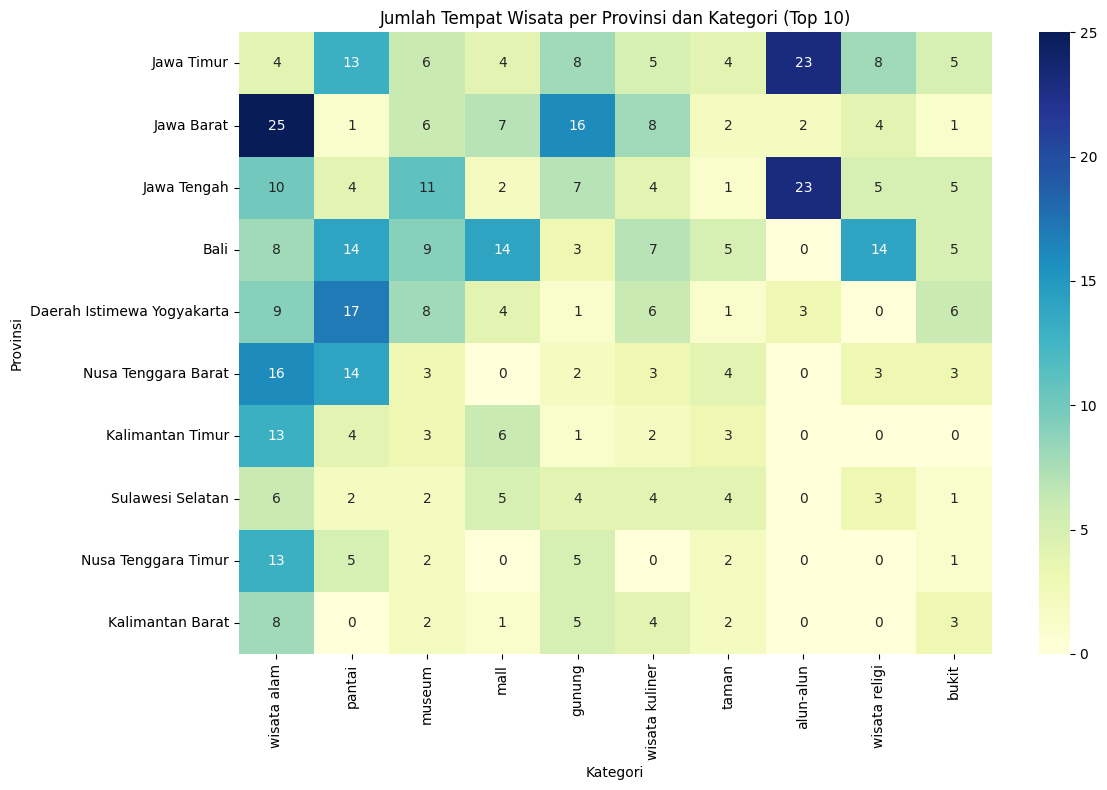

In [11]:
pivot_table = pd.crosstab(df['provinsi'], df['kategori'])
top_kat = df['kategori'].value_counts().nlargest(10).index
top_prov = df['provinsi'].value_counts().nlargest(10).index
pivot_filtered = pivot_table.loc[top_prov, top_kat]
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_filtered, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Jumlah Tempat Wisata per Provinsi dan Kategori (Top 10)')
plt.xlabel("Kategori")
plt.ylabel("Provinsi")
plt.tight_layout()
plt.show()

### EDA Univariate

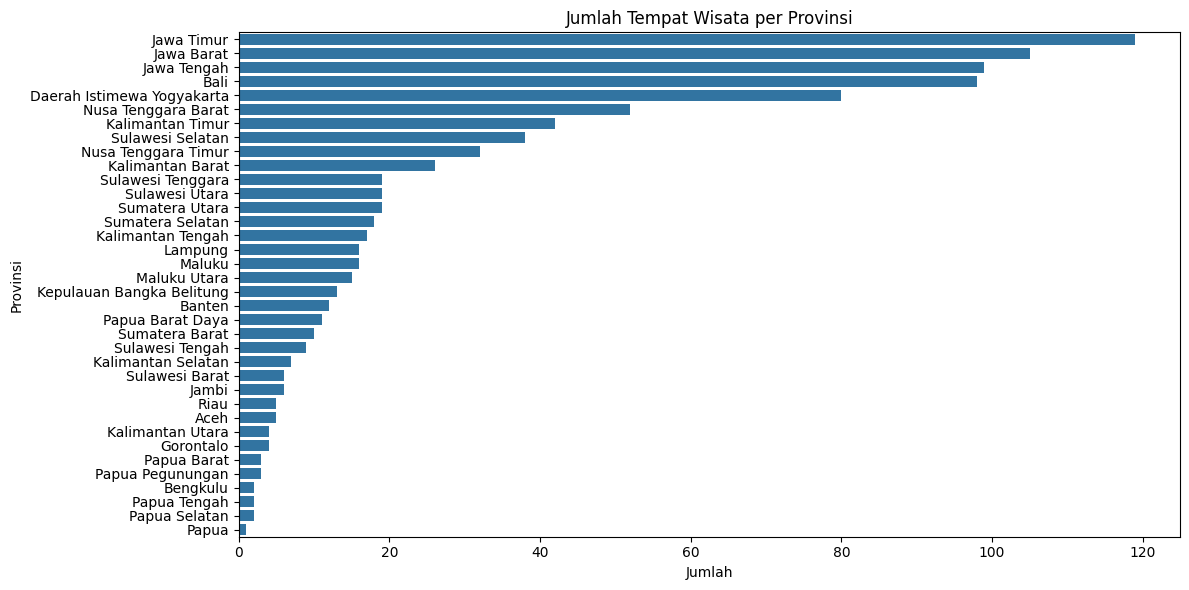

In [12]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='provinsi', order=df['provinsi'].value_counts().index)
plt.title('Jumlah Tempat Wisata per Provinsi')
plt.xlabel('Jumlah')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

### Top 10 Kabupaten dengan Jumlah Wisata Terbanyak

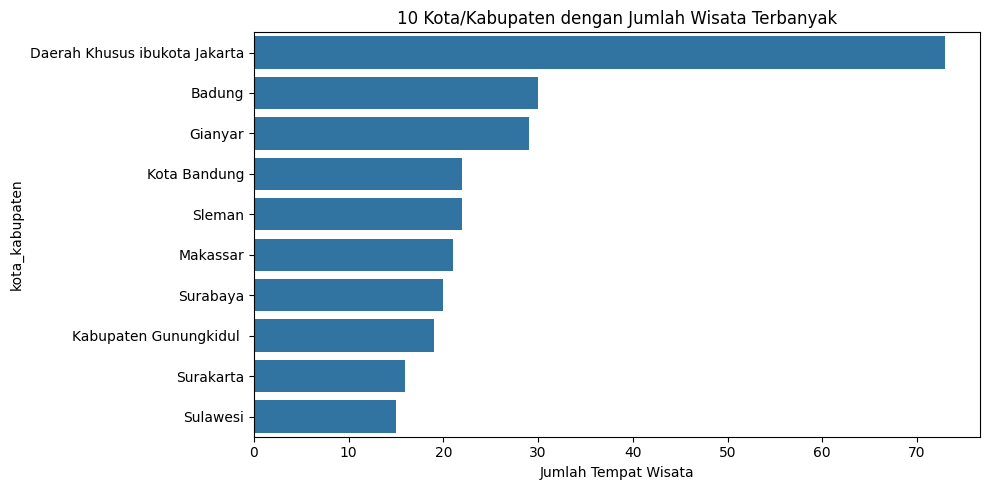

In [13]:
plt.figure(figsize=(10, 5))
top_kota = df['kota_kabupaten'].value_counts().head(10)
sns.barplot(x=top_kota.values, y=top_kota.index)
plt.title('10 Kota/Kabupaten dengan Jumlah Wisata Terbanyak')
plt.xlabel('Jumlah Tempat Wisata')
plt.tight_layout()
plt.show()

## **Data Preparation**

### **CLEANING DATA**

#### Cek Missing Value

In [14]:
print("="*40)
print(df.isnull().sum())
print("="*40)

kategori             0
nama_wisata          0
latitude             0
longitude            0
alamat               0
provinsi            90
kota_kabupaten      18
nama_lengkap         0
path_gambar          0
deskripsi_bersih    27
dtype: int64


#### Penangan Missing Value Diisi Dengan Nilai Modus

In [15]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

print(df.isnull().sum())

kategori            0
nama_wisata         0
latitude            0
longitude           0
alamat              0
provinsi            0
kota_kabupaten      0
nama_lengkap        0
path_gambar         0
deskripsi_bersih    0
dtype: int64


#### Jumlah baris duplikat:

In [16]:
print("="*40)
print(f" Jumlah baris duplikat: {df.duplicated().sum()}")
print("="*40)


 Jumlah baris duplikat: 0


### **TEXT PREPOCESSING**

In [17]:
# Download stopwords
nltk.download('stopwords', quiet=True)
stopwords_indonesia = stopwords.words('indonesian')



def bersihkan_teks(teks):
    """Membersihkan teks deskripsi"""
    if pd.isna(teks):
        return ""
    
  
    # CEK PLACEHOLDER 
    if 'deskripsi tidak ditemukan' in str(teks).lower():
        return ""
    if 'berikut ini adalah daftar' in str(teks).lower():
        return ""
    
    # Ubah ke huruf kecil
    teks = str(teks).lower()
    
    # Hapus karakter aneh
    teks = re.sub(r'[^\x00-\x7F]+', ' ', teks)
    
    # Hapus format wiki
    teks = re.sub(r"==.*?==", "", teks)
    
    # Hapus kalimat pembuka yang tidak berguna
    teks = re.sub(r"berikut ini adalah daftar.*?\.", "", teks)
    teks = re.sub(r"latar belakang.*?\.", "", teks)
    teks = re.sub(r"sejarah singkat.*?\.", "", teks)
    
    # Hapus tanda baca dan angka
    teks = re.sub(r'[^a-z\s]', ' ', teks)
    
    # Hapus spasi berlebih
    teks = re.sub(r'\s+', ' ', teks).strip()
    
    # Hapus stopwords
    kata_kata = teks.split()
    kata_kata = [k for k in kata_kata if k not in stopwords_indonesia and len(k) > 2]
    
    return ' '.join(kata_kata)



# PROSES PREPROCESSING


print("="*60)
print("PROSES PREPROCESSING ")
print("="*60)

# Buat df_clean
df_clean = df.copy()

print(f"Data awal: {len(df_clean)} baris")

# 1. BERSIHKAN DESKRIPSI
df_clean['deskripsi_bersih'] = df_clean['deskripsi_bersih'].apply(bersihkan_teks)

# 2. HAPUS BARIS DENGAN DESKRIPSI KOSONG
before = len(df_clean)
df_clean = df_clean[df_clean['deskripsi_bersih'] != ""]
print(f"Menghapus {before - len(df_clean)} baris dengan deskripsi tidak valid")

# 3. BERSIHKAN PROVINSI
df_clean['provinsi'] = df_clean['provinsi'].str.strip()

# 4. PERBAIKI TYPO KATEGORI
kategori_mapping = {
    'wisate alam': 'wisata alam',
    'wisath alam': 'wisata alam',
    'wisatr alam': 'wisata alam',
    'wisaub alam': 'wisata alam',
    'wisawa alam': 'wisata alam',
    'wisawi alam': 'wisata alam',
}
df_clean['kategori'] = df_clean['kategori'].replace(kategori_mapping)

# 5. STANDARISASI KATEGORI
df_clean['kategori'] = df_clean['kategori'].str.lower().str.strip()

print(f"\nData akhir: {len(df_clean)} baris")
print(f"Data yang hilang: {len(df) - len(df_clean)} baris")

print("\nContoh hasil:")
df_clean[['nama_wisata', 'kategori', 'deskripsi_bersih']].head(10)

PROSES PREPROCESSING 
Data awal: 1025 baris
Menghapus 202 baris dengan deskripsi tidak valid

Data akhir: 823 baris
Data yang hilang: 202 baris

Contoh hasil:


,nama_wisata,kategori,deskripsi_bersih
1,Air Terjun Bantimurung,air terjun,air terjun bantimurung salah air terjun eksoti...
4,Air Terjun Bidadari,air terjun,daftar lengkap dijadikan acuan
5,Air Terjun Coban Rondo,air terjun,air terjun coban rondo air terjun terletak kec...
8,Air Terjun Dolo,air terjun,air terjun dolo salah wisata air terjun terlet...
11,Air Terjun Kedung Kayang,air terjun,kabupaten magelang bahasa jawa hanacaraka pego...
13,Air Terjun Matayangu,air terjun,daftar lengkap dijadikan acuan
14,Air Terjun Moramo,air terjun,air terjun moramo terletak kawasan hutan suaka...
15,Air Terjun Sambangan,air terjun,kabupaten buleleng bahasa bali kabupat bul sal...
16,Air Terjun Sendang Gile,air terjun,air terjun sendang gile air terjun terletak de...
17,Air Terjun Sri Gethuk,air terjun,daerah istimewa yogyakarta disingkat yogyakart...


In [18]:
preferred_categories = ["gunung", "taman", "pantai"]
user_provinsi = "Jawa Timur"

filtered_df = df_clean[df_clean['provinsi'].str.lower() == user_provinsi.lower()].copy()
filtered_df['label'] = filtered_df['kategori'].apply(lambda x: 1 if x in preferred_categories else 0)


print("Data setelah filter:", filtered_df.shape)

Data setelah filter: (150, 11)


## **Modelling: Skor Cosine Similarity**

In [19]:
tfidf = TfidfVectorizer(stop_words=stopwords_indonesia)
tfidf_matrix = tfidf.fit_transform(filtered_df['deskripsi_bersih'])

In [20]:
user_pref_kategori = " ".join(preferred_categories)
user_vector = tfidf.transform([user_pref_kategori])
cosine_sim = cosine_similarity(user_vector, tfidf_matrix).flatten()

In [21]:
filtered_df['score'] = cosine_sim

# **Feature Engineering**

In [22]:
filtered_df['desc_len'] = filtered_df['deskripsi_bersih'].apply(lambda x: len(str(x).split()))

In [23]:
le_kategori = LabelEncoder()
le_provinsi = LabelEncoder()

In [24]:
filtered_df['desc_len'] = filtered_df['deskripsi_bersih'].apply(lambda x: len(str(x).split()))
filtered_df['kategori_enc'] = le_kategori.fit_transform(filtered_df['kategori'])
filtered_df['provinsi_enc'] = le_provinsi.fit_transform(filtered_df['provinsi'])
filtered_df['is_preferred_category'] = filtered_df['kategori'].apply(lambda x: 1 if x in preferred_categories else 0)

In [25]:
X = filtered_df[['kategori_enc', 'provinsi_enc', 'desc_len', 'is_preferred_category']]
y = filtered_df['score']

In [26]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [28]:
df_clean['kategori'].unique()

<ArrowStringArray>
[     'air terjun',       'alun-alun',           'bukit',           'candi',
          'gunung',  'kebun binatang',          'lembah',            'mall',
         'monumen',          'museum',          'pantai',      'rumah adat',
           'taman', 'wahana keluarga',     'wisata alam',  'wisata edukasi',
 'wisata kerajaan',  'wisata kuliner',  'wisata lampion',   'wisata religi',
  'wisata tematik']
Length: 21, dtype: str

# **Modelling dengan TensorFlow**

In [29]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-06-01 18:11:56.041928: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-01 18:12:04.493742: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-01 18:12:08.764432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780337534.833190    5154 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780337536.358824    5154 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780337547.470410    5154 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

[]


2026-06-01 18:13:03.151049: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(4,)),          # 4 fitur input

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.0000e+00 - loss: 0.7619 - val_accuracy: 0.0000e+00 - val_loss: 0.7685
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0312 - loss: 0.7501 - val_accuracy: 0.0000e+00 - val_loss: 0.7520
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1562 - loss: 0.7320 - val_accuracy: 0.0000e+00 - val_loss: 0.7355
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1875 - loss: 0.7200 - val_accuracy: 0.0833 - val_loss: 0.7184
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3229 - loss: 0.7011 - val_accuracy: 0.2500 - val_loss: 0.7003
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4792 - loss: 0.6882 - val_accuracy: 0.6667 - val_loss: 0.6822
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6562 - loss: 0.6717 - val_accuracy: 0.7500 - val_loss: 0.6640
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7083 - loss: 0.6569 - val_accuracy: 0.7500 - 

# **Evaluasi Model**

In [32]:
# Ambil ground truth dan hasil rekomendasi
filtered_df['label'] = filtered_df['kategori'].apply(lambda x: 1 if x in preferred_categories else 0)

# Urutkan berdasarkan skor cosine similarity
filtered_df_sorted = filtered_df.sort_values(by='score', ascending=False)
top_k = 10
top_k_recommendations = filtered_df_sorted.head(top_k)
ground_truth = filtered_df[filtered_df['label'] == 1]['nama_wisata'].values
predicted = top_k_recommendations['nama_wisata'].values

def precision_recall_at_k(ground_truth, predicted, k):
    predicted_k = predicted[:k]
    relevant = set(ground_truth)
    retrieved = set(predicted_k)
    true_positive = relevant.intersection(retrieved)

    precision = len(true_positive) / k
    recall = len(true_positive) / len(relevant) if len(relevant) > 0 else 0.0

    return precision, recall

precision, recall = precision_recall_at_k(ground_truth, predicted, top_k)
print(f"Precision@{top_k}: {precision:.2f}")
print(f"Recall@{top_k}: {recall:.2f}")

Precision@10: 1.00
Recall@10: 0.38


In [33]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f} | MAE: {mae:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7667 - loss: 0.1575
Loss: 0.1575 | MAE: 0.7667


# **Prediksi & Rekomendasi**

In [34]:
filtered_df['predicted_score'] = model.predict(X_scaled).flatten()
top_rekomendasi = filtered_df.sort_values(by='predicted_score', ascending=False).head(10)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


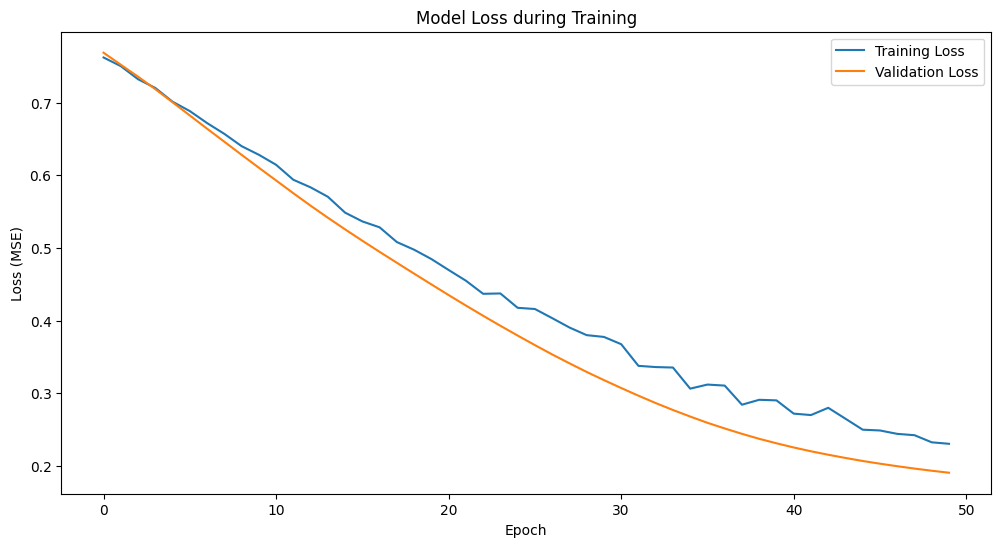

In [35]:
import matplotlib.pyplot as plt
# Visualisasi hasil evaluasi model
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss during Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

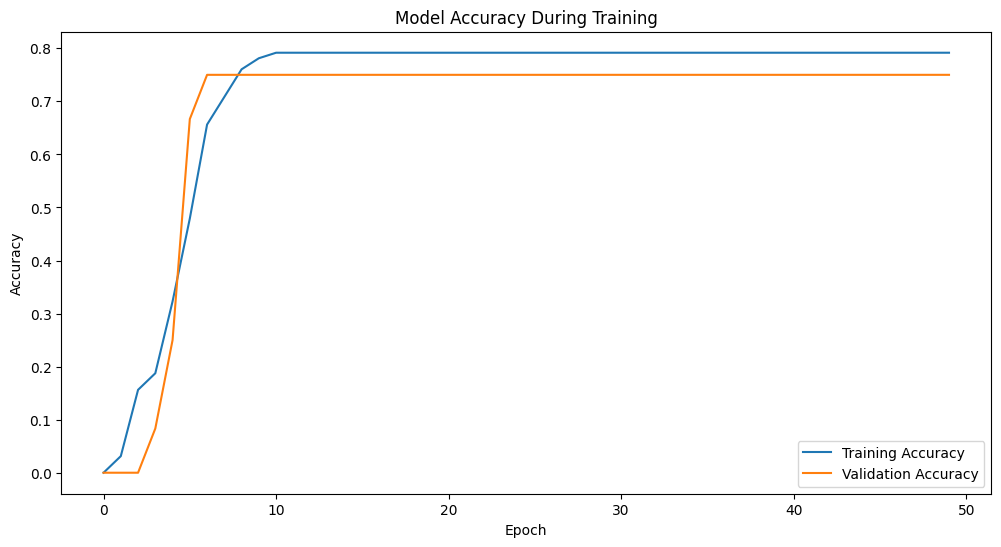

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy During Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

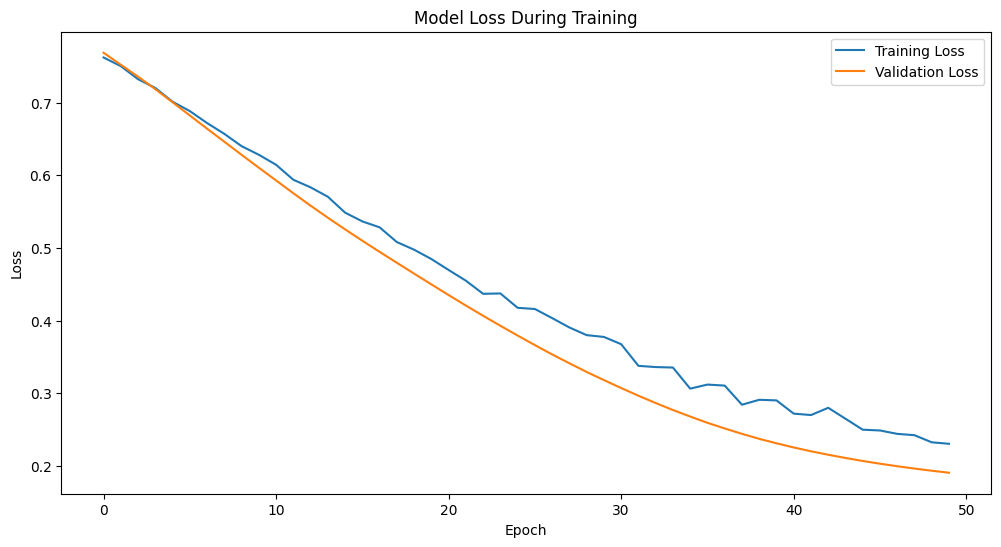

In [37]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Rekomendasi dari Preferensi User

In [38]:
def rekomendasi_wisata_berbobot(preferred_categories, user_provinsi, df, model, le_kategori, le_provinsi, scaler, weight_model=0.3, weight_tfidf=0.7):
    # Filter data sesuai provinsi
    filtered_df = df[df['provinsi'].str.lower() == user_provinsi.lower()].copy()
    if 'deskripsi_bersih' not in filtered_df.columns:
        filtered_df['deskripsi_bersih'] = filtered_df['deskripsi'].apply(bersihkan_deskripsi)

    # Hitung TF-IDF cosine similarity
    tfidf = TfidfVectorizer(stop_words=stopwords_indonesia)
    tfidf_matrix = tfidf.fit_transform(filtered_df['deskripsi_bersih'])
    user_pref_kategori = " ".join(preferred_categories)
    user_vector = tfidf.transform([user_pref_kategori])
    cosine_sim = cosine_similarity(user_vector, tfidf_matrix).flatten()
    filtered_df['cosine_score'] = cosine_sim

    # Feature engineering untuk model
    filtered_df['desc_len'] = filtered_df['deskripsi_bersih'].apply(lambda x: len(str(x).split()))
    filtered_df['kategori_enc'] = le_kategori.transform(filtered_df['kategori'])
    filtered_df['provinsi_enc'] = le_provinsi.transform(filtered_df['provinsi'])
    filtered_df['is_preferred_category'] = filtered_df['kategori'].apply(lambda x: 1 if x in preferred_categories else 0)

    X = filtered_df[['kategori_enc', 'provinsi_enc', 'desc_len', 'is_preferred_category']]
    X_scaled = scaler.transform(X)

    # Prediksi skor dengan model TensorFlow
    filtered_df['model_score'] = model.predict(X_scaled).flatten()
    filtered_df['final_score'] = weight_model * filtered_df['model_score'] + weight_tfidf * filtered_df['cosine_score']

    # Ambil top 10 rekomendasi berdasarkan final_score
    top_rekomendasi = filtered_df.sort_values(by='final_score', ascending=False).head(10)

    # Tampilkan kolom yang diminta plus skor
    return top_rekomendasi[['nama_wisata', 'provinsi', 'alamat', 'deskripsi_bersih', 'kota_kabupaten', 'final_score', 'cosine_score', 'model_score']]

In [39]:
valid_categories = df_clean["kategori"].unique()

filtered_preferred_categories = [cat for cat in preferred_categories if cat in valid_categories]

if not filtered_preferred_categories:
    print("Maaf, tidak ada kategori yang cocok dengan preferensi Anda.")
else:
    hasil_rekomendasi = rekomendasi_wisata_berbobot(
        filtered_preferred_categories,
        user_provinsi,
        df_clean,
        model,
        le_kategori,
        le_provinsi,
        scaler
    )
    print(hasil_rekomendasi)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
                nama_wisata    provinsi  \
512        Pantai Rajegwesi  Jawa Timur   
574  Taman Nasional Baluran  Jawa Timur   
453             Pantai Boom  Jawa Timur   
529       Pantai Tambakrejo  Jawa Timur   
225           Gunung Semeru  Jawa Timur   
169           Gunung Arjuno  Jawa Timur   
509        Pantai Plengkung  Jawa Timur   
239         Gunung Welirang  Jawa Timur   
473           Pantai Klayar  Jawa Timur   
511            Pantai Popoh  Jawa Timur   

                                                alamat  \
512  Pantai Rajegwesi, Rajegwesi, Banyuwangi, Jawa ...   
574  Taman Nasional Baluran, Situbondo, Banyuwangi,...   
453  Pantai Boom, Krajan, Banyuwangi, Kampungmandar...   
529  Pantai Tambakrejo, Jalan Pantai, Tambakrejo, B...   
225  Gunung Semeru, Lumajang, Jawa Timur, Jawa, Ind...   
169  Gunung Arjuno, Bumirejo, Kabupaten Malang, Jaw...   
509  Pantai Plengkung, G-Land, Banyuwangi, Jawa Tim...   
239  Gunung Welirang, Pa

In [40]:
model.save('model_ann.keras')

In [41]:
!pip install tensorflowjs


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [42]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7667 - loss: 0.1575
Accuracy: 0.7666666507720947
